In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import pandas as pd
import matplotlib.cm as mplcm
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import cartopy.crs as ccrs
import numpy as np


In [3]:
import numpy as np
import pandas as pd
import requests
from datetime import datetime

def noaa_sealevel(station, start_yr, end_yr):
    """
    Downloads hourly observed water level from NOAA tide gauge.

    Parameters:
        station (int): NOAA station ID
        start_yr (int): start year
        end_yr (int): end year

    Returns:
        sl (numpy array): sea level (meters)
        md (pandas DatetimeIndex): time vector (hourly)
    """

    # ==========================
    # Create uniform hourly time base
    # ==========================
    md = pd.date_range(
        start=f"{start_yr}-01-01 00:00:00",
        end=f"{end_yr}-12-31 23:00:00",
        freq="h"
    )

    mdi_list = []
    sli_list = []

    # ==========================
    # Loop over years
    # ==========================
    for yr in range(start_yr, end_yr + 1):
        url = (
            "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
            f"?product=hourly_height"
            f"&application=NOS.COOPS.TAC.WL"
            f"&begin_date={yr}0101"
            f"&end_date={yr}1231"
            f"&datum=STND"
            f"&station={station}"
            f"&time_zone=GMT"
            f"&units=metric"
            f"&format=csv"
        )

        try:
            df = pd.read_csv(url)

            # NOAA CSV usually has columns: Date Time, Water Level, etc.
            df.columns = df.columns.str.strip()

            time_col = df.columns[0]
            sl_col = df.columns[1]

            mdi = pd.to_datetime(df[time_col], errors='coerce')
            sli = pd.to_numeric(df[sl_col], errors='coerce')

            mdi_list.append(mdi)
            sli_list.append(sli)

        except Exception as e:
            print(f"Failed for year {yr}: {e}")

    # ==========================
    # Combine all years
    # ==========================
    if len(sli_list) > 0:
        mdi_all = pd.concat(mdi_list).reset_index(drop=True)
        sli_all = pd.concat(sli_list).reset_index(drop=True)

        # Create empty series aligned to full time base
        sl_series = pd.Series(index=md, dtype=float)

        # Insert values
        sl_series.loc[mdi_all] = sli_all.values

        sl = sl_series.values

        print("md: datetime index (GMT); sl: sea level (meters)")

    else:
        sl = np.full(len(md), np.nan)
        print("No data retrieved.")

    return sl, md

In [4]:
## downloading the data from https://tidesandcurrents.noaa.gov/ using api
station = 8447930  ## station id of woodhole tg
t0 = 2023 
tf = 2025

sl, time = noaa_sealevel(station, t0, tf)

df_tg = pd.DataFrame({'time': pd.to_datetime(time),'sea_level': sl})#, #index=pd.to_datetime(time))
df_tg['sla'] = df_tg['sea_level'] - df_tg['sea_level'].mean()
print(df_tg.head())


md: datetime index (GMT); sl: sea level (meters)
                 time  sea_level       sla
0 2023-01-01 00:00:00      1.209 -0.075666
1 2023-01-01 01:00:00      1.150 -0.134666
2 2023-01-01 02:00:00      1.102 -0.182666
3 2023-01-01 03:00:00      1.078 -0.206666
4 2023-01-01 04:00:00      1.080 -0.204666


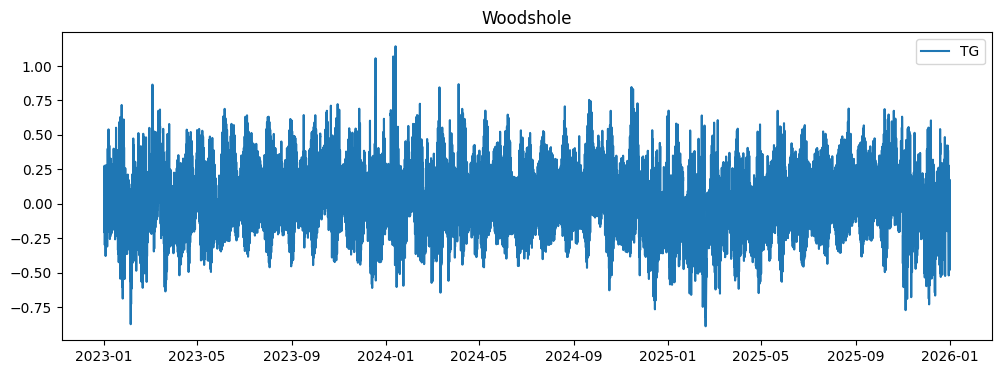

In [5]:
### plot the tg data 
## Here we are plotting the sea level after removing the mean
plt.figure(figsize=(12, 4))
plt.plot(df_tg['time'],df_tg['sla'],label='TG')
plt.title('Woodshole')
plt.legend()


In [6]:
## Loading the swot data

path = '/Users/anupn/Desktop/summer_school/swot_data/expert/'
  # dont forget to change this to your local one
files = sorted(os.listdir(path))
all_files = [os.path.join(path, f) for f in files]

In [7]:
def drop_large_vars(ds):
    to_drop = [v for v in ['i_num_line', 'i_num_pixel'] if v in ds]
    return ds.drop_vars(to_drop)
dm = xr.open_mfdataset(all_files,concat_dim='cycle',combine='nested',
    preprocess=drop_large_vars)

In [8]:
# get the first and last dates

# Flatten and drop NaT values
valid_times = dm['time'].values.flatten()
valid_times = valid_times[~pd.isnull(valid_times)]

# Select first valid time and format
date_start = pd.to_datetime(valid_times[0]).strftime('%Y-%m-%d')
date_end = pd.to_datetime(valid_times[-1]).strftime('%Y-%m-%d')
print(date_start)
print(date_end)

2023-07-30
2025-03-06


In [9]:
## TG location 
lat_tg = 41.31
lon_tg = -70.40 + 360  # SWOT convention

## Zoomed bounding boxes for the region aroung TG
lon_min = -73
lon_max=-68
lat_min=40
lat_max= 45

In [17]:
ds.ssha_unfiltered

<xarray.DataArray 'ssha_unfiltered' (num_lines: 9860, num_pixels: 69)> Size: 5MB
[680340 values with dtype=float64]
Coordinates:
    latitude   (num_lines, num_pixels) float64 5MB 78.27 78.25 ... -78.25 -78.27
    longitude  (num_lines, num_pixels) float64 5MB 214.4 214.4 ... 21.3 21.3
Dimensions without coordinates: num_lines, num_pixels
Attributes:
    comment:              Height of the sea surface anomaly with all correcti...
    long_name:            sea surface height anomaly calibrated and edited
    standard_name:        sea_surface_height_above_mean_sea_level
    units:                m
    ancillary_variables:  quality_flag

In [10]:
#Tide gauges measure total water level (TWL), that is, it includes tides and atmospheric effects to it. 
#So to compare SWOT data to tide gauge, we need to re-add tides and DAC to it, as well as the mean sea-surface height

dm['twl'] = dm['ssha_unedited']  + dm['ocean_tide'] + dm['dac'] + dm['mss'] + dm['internal_tide']
# we then remove average so we can compare with the tide gauge
dm['twla'] = dm['twl']-dm['twl'].mean(dim=('cycle'))

In [11]:
# Extract nearest SWOT pixel
swot_lat = np.array(dm['latitude'])
swot_lon = np.array(dm['longitude'])

tg_lat = float(lat_tg)
tg_lon = float(lon_tg)
tg_sl  = np.array(df_tg['sla'])

# Distance to all SWOT points
dists = np.hypot(swot_lat - tg_lat, swot_lon - tg_lon)
il, ip = np.where(dists == np.min(dists))

# Convert to scalars
il = int(il[0])
ip = int(ip[0])


nearest_lon = (dm.longitude.isel(num_lines=il,num_pixels=ip).values)
nearest_lat = (dm.latitude.isel(num_lines=il,num_pixels=ip).values)
print(nearest_lon,nearest_lat)

# SWOT SLA at nearest pixel
swot_sl = np.array(dm['twla'][:, il, ip]).flatten()

# SWOT time (now 1-D)
swot_time = pd.to_datetime(dm.time[:, il].values)

# Interpolate TG SLA to SWOT timestamps
tg_sl_interp = np.interp(
    swot_time.astype(np.int64),
    df_tg.time.astype(np.int64),
    tg_sl
)


289.593152 41.315006


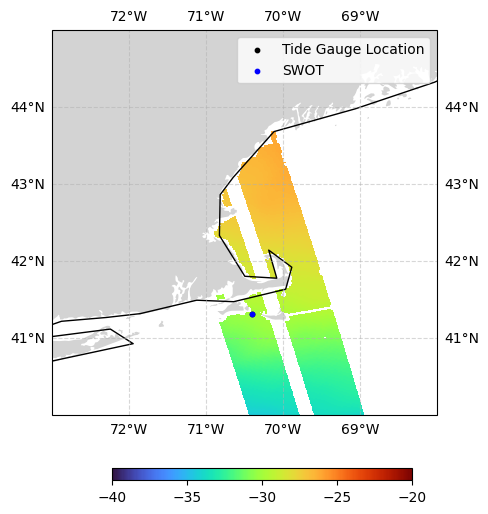

In [12]:
ds = xr.open_dataset(all_files[1])
fig, ax = plt.subplots(1, 1,figsize=(10, 5),subplot_kw=dict(projection=ccrs.PlateCarree()))
twl = ds.ssha_unfiltered + ds.ocean_tide + ds.dac + ds.mss
pcm = ax.pcolormesh(ds.longitude,ds.latitude,twl,cmap="turbo",vmin = -40, vmax = -20, transform=ccrs.PlateCarree())
ax.coastlines(resolution="110m", linewidth=1)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
ax.scatter(lon_tg,lat_tg,s=10,color='black',transform=ccrs.PlateCarree(),label='Tide Gauge Location')
ax.scatter(nearest_lon,nearest_lat,s=10,color='blue',transform=ccrs.PlateCarree(),label='SWOT')
# --- Region of interest ---
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
cax = fig.add_axes([0.38, -0.02, 0.3, 0.025])  # [left, bottom, width, height]
ax.legend()
cb = fig.colorbar(pcm, cax=cax,orientation="horizontal")

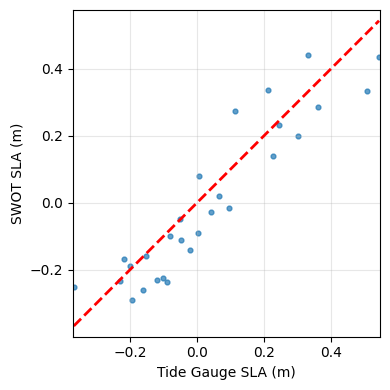

In [13]:

# Scatter plot
plt.figure(figsize=(4,4))
plt.scatter(tg_sl_interp, swot_sl, s=12, alpha=0.7)
vmin = np.nanmin([tg_sl_interp.min(), swot_sl.min()])
vmax = np.nanmax([tg_sl_interp.max(), swot_sl.max()])
plt.plot([vmin, vmax], [vmin, vmax],
         'r--', lw=2, label='1:1 line')

# Make axes square
plt.axis('equal')
plt.xlim(vmin, vmax)
plt.ylim(vmin, vmax)
plt.xlabel("Tide Gauge SLA (m)")
plt.ylabel("SWOT SLA (m)")


plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



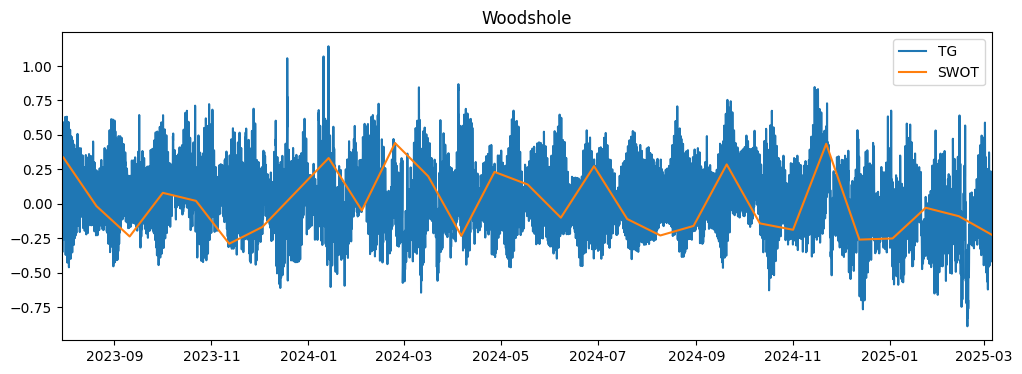

In [14]:

# plot
## Here we are plotting the sea level after removing the mean
plt.figure(figsize=(12, 4))
plt.plot(df_tg['time'],df_tg['sla'],label='TG')
plt.title('Woodshole')
plt.legend()
plt.plot(swot_time,swot_sl,label='SWOT')
plt.xlim(np.datetime64(date_start),np.datetime64(date_end))
plt.legend()
plt.show()

In [15]:
for t_swot, s_swot in zip(dm.time[:, il].values.flatten(), swot_sl):

    # nearest TG index
    idx_tg = np.argmin(np.abs(df_tg.time.values - t_swot))

    print(
        "SWOT:", t_swot, s_swot,
        " | TG:", df_tg.time.values[idx_tg], tg_sl[idx_tg]
    )

SWOT: 2023-07-30T20:26:37.573848320 0.3364750000000001  | TG: 2023-07-30T20:00:00.000000000 0.12833439781021894
SWOT: 2023-08-20T17:11:42.923928832 -0.01672500000000099  | TG: 2023-08-20T17:00:00.000000000 0.12633439781021893
SWOT: 2023-09-10T13:56:49.037621376 -0.23682500000000317  | TG: 2023-09-10T14:00:00.000000000 -0.08966560218978104
SWOT: 2023-10-01T10:41:51.650880512 0.07977499999999793  | TG: 2023-10-01T11:00:00.000000000 0.07233439781021889
SWOT: 2023-10-22T07:26:56.039302784 0.0214749999999988  | TG: 2023-10-22T07:00:00.000000000 0.0933343978102188
SWOT: 2023-11-12T04:12:01.190604416 -0.28952500000000114  | TG: 2023-11-12T04:00:00.000000000 -0.178665602189781
SWOT: 2023-12-03T00:57:06.736826240 -0.1680250000000001  | TG: 2023-12-03T01:00:00.000000000 -0.21966560218978115
SWOT: 2024-01-13T18:27:16.238443904 0.3322749999999992  | TG: 2024-01-13T18:00:00.000000000 0.6093343978102188
SWOT: 2024-02-03T15:12:22.452255232 -0.048125000000002416  | TG: 2024-02-03T15:00:00.000000000 -0